In [1]:
!pip install sentence-transformers scikit-learn seaborn matplotlib

In [2]:
sentences = [
    # Cricket (3 sentences)
    "The batsman hit a magnificent century in the final over.",
    "India won the match by 6 wickets against Australia.",
    "The spinner took five wickets and demolished the batting lineup.",

    # Cooking (3 sentences)
    "Saute the onions in olive oil until they turn golden brown.",
    "Add the spices and stir continuously to avoid burning.",
    "The dish is ready when the sauce thickens and coats the spoon.",

    # Cybersecurity (4 sentences)
    "The hacker exploited a SQL injection vulnerability in the login form.",
    "Two-factor authentication significantly reduces the risk of unauthorized access.",
    "The firewall blocked over 10,000 suspicious connection attempts overnight.",
    "Always encrypt sensitive data both in transit and at rest."
]

print(f"Total sentences: {len(sentences)}")

Total sentences: 10


In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print(f"Embedding shape: {embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


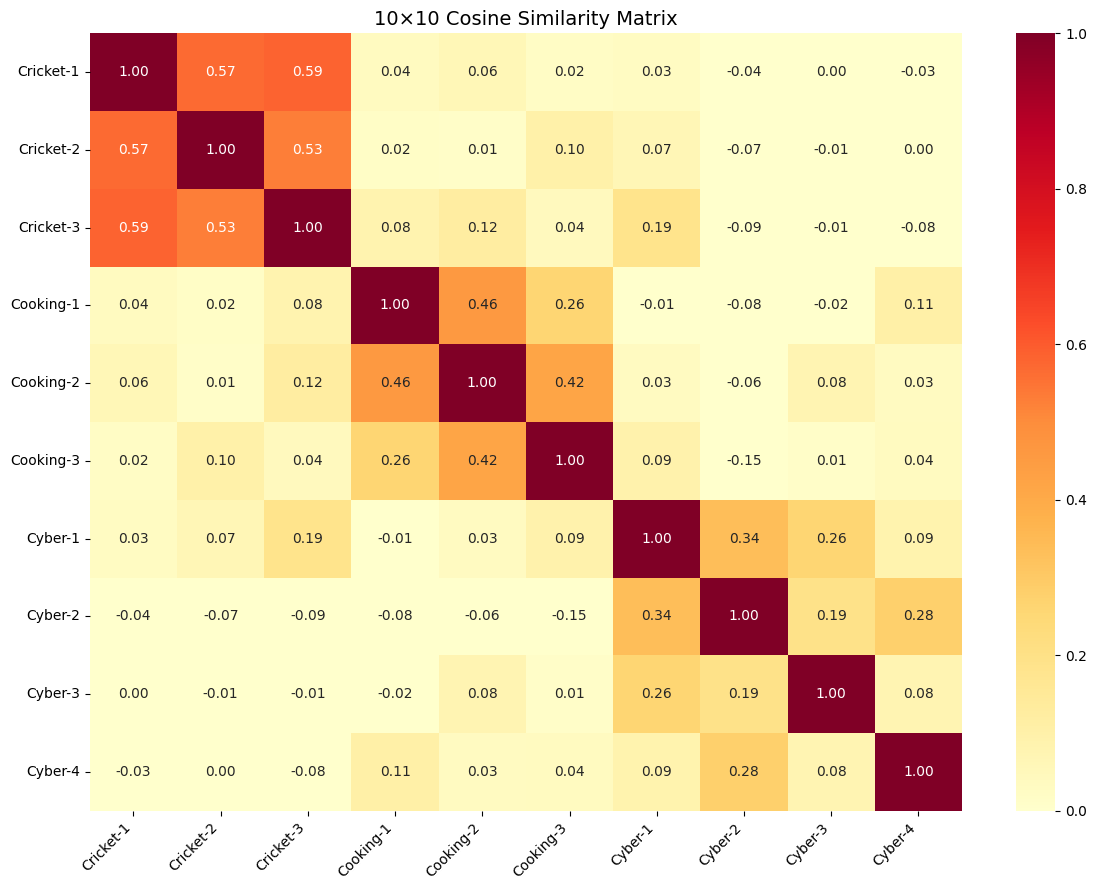

In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

labels = [
    "Cricket-1", "Cricket-2", "Cricket-3",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "Cyber-1",   "Cyber-2",   "Cyber-3",   "Cyber-4"
]

plt.figure(figsize=(12, 9))
sns.heatmap(
    similarity_matrix,
    annot=True, fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="YlOrRd",
    vmin=0, vmax=1
)
plt.title("10×10 Cosine Similarity Matrix", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 indices
top_indices = np.argsort(similarities)[::-1][:2]

print(f"Query: '{query}'\n")
print("Top 2 most similar sentences:")
for rank, idx in enumerate(top_indices, 1):
    print(f"  Rank {rank}: \"{sentences[idx]}\"")
    print(f"           Similarity Score: {similarities[idx]:.4f}")

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:
  Rank 1: "The spinner took five wickets and demolished the batting lineup."
           Similarity Score: 0.6563
  Rank 2: "India won the match by 6 wickets against Australia."
           Similarity Score: 0.6463
